In [1]:
import os, sys, json, hashlib, random, warnings, time, re, io, contextlib, urllib.request
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import wilcoxon, friedmanchisquare, rankdata

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, balanced_accuracy_score, confusion_matrix)
import matplotlib.pyplot as plt
from deap import creator, base, tools

warnings.filterwarnings("ignore")

# --- GRAPE bootstrap (bdsul/grape) ---
GRAPE_BRANCH = "main"
GRAPE_FILES = ["grape.py", "algorithms.py", "functions.py"]
for fname in GRAPE_FILES:
    if not os.path.exists(fname):
        urllib.request.urlretrieve(
            f"https://raw.githubusercontent.com/bdsul/grape/{GRAPE_BRANCH}/{fname}", fname)
for fname in GRAPE_FILES:                       # compatibility shims (NumPy 2.x / Py 3.12+)
    src = open(fname, encoding="utf-8").read()
    fixed = (src.replace("random.randint(0,1e10)", "random.randint(0,10**10)")
                .replace("np.NaN", "np.nan").replace("np.NAN", "np.nan"))
    if fixed != src:
        open(fname, "w", encoding="utf-8").write(fixed)
import grape, algorithms
from functions import add, sub, mul, pdiv
_GE_FUNCS = {"add": add, "sub": sub, "mul": mul, "pdiv": pdiv}

try:
    import shap; HAS_SHAP = True
except Exception as exc:
    HAS_SHAP = False; print("shap unavailable, using model-based importances:", type(exc).__name__)
try:
    from xgboost import XGBClassifier; HAS_XGB = True
except Exception:
    HAS_XGB = False

# --- configuration ---
GLOBAL_SEED = 42
PAPER_SCALE = True
N_SEEDS = 30 if PAPER_SCALE else 15
SEEDS = tuple(range(1, N_SEEDS + 1))
POPULATION_SIZE = 120
N_GENERATIONS = 30
N_CONSTRUCTED = 5
LLM_BACKEND = "cached"          # "api" + ANTHROPIC_API_KEY for a live LLM run
EPS = 1e-8
# GRAPE / BDS parameters
CODON_SIZE = 255
MAX_TREE_DEPTH = 17
MIN_INIT_DEPTH = 4
MAX_INIT_DEPTH = 10
P_CROSSOVER = 0.8
P_MUTATION_PER_CODON = 0.01
CODON_CONSUMPTION = "lazy"
GENOME_REPRESENTATION = "list"

SELECTION_ARMS = ["none", "random", "mi", "corr", "llm"]
CONSTRUCTION_ARMS = ["raw", "random", "llm"]

def set_seeds(seed):
    random.seed(seed); np.random.seed(seed); os.environ["PYTHONHASHSEED"] = str(seed)
set_seeds(GLOBAL_SEED)
FIGURES = Path("figures"); FIGURES.mkdir(exist_ok=True)
print(f"Engine ready (GRAPE library) | seeds={N_SEEDS} | xgboost={HAS_XGB} | shap={HAS_SHAP} | backend={LLM_BACKEND}")

Engine ready (GRAPE library) | seeds=30 | xgboost=True | shap=True | backend=cached


In [2]:
DATA_DIR = Path("data"); DATA_DIR.mkdir(exist_ok=True)

def _cached_csv(url, fname, **kw):
    path = DATA_DIR / fname
    if not path.exists():
        urllib.request.urlretrieve(url, path)
    return pd.read_csv(path, **kw)

def load_wbcd():
    d = load_breast_cancer()
    X = pd.DataFrame(d.data, columns=list(d.feature_names))
    y = pd.Series((d.target == 0).astype(int), name="malignant")   # 1 = malignant
    return X, y

def load_pima():
    cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
            "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
    df = _cached_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/"
                     "pima-indians-diabetes.data.csv", "pima.csv", header=None, names=cols)
    return df.drop(columns="Outcome"), df["Outcome"].astype(int).rename("diabetes")

def load_cleveland():
    df = _cached_csv("https://raw.githubusercontent.com/kb22/Heart-Disease-Prediction/"
                     "master/dataset.csv", "cleveland.csv", encoding="utf-8-sig")
    y = (df["target"] > 0).astype(int).rename("heart_disease")
    return df.drop(columns="target"), y

DATASETS = {
    "wbcd":      {"loader": load_wbcd,      "k": 8},
    "pima":      {"loader": load_pima,      "k": 4},
    "cleveland": {"loader": load_cleveland, "k": 6},
}

def prepare_dataset(key, seed=GLOBAL_SEED):
    X, y = DATASETS[key]["loader"]()
    features = list(X.columns)
    Xtr_raw, Xte_raw, ytr, yte = train_test_split(
        X.values.astype(float), y.values.astype(int), test_size=0.30,
        stratify=y.values, random_state=seed)
    scaler = StandardScaler().fit(Xtr_raw)
    return dict(key=key, features=features, k=DATASETS[key]["k"],
                Xtr_raw=Xtr_raw, Xte_raw=Xte_raw, ytr=ytr, yte=yte,
                Xtr=scaler.transform(Xtr_raw), Xte=scaler.transform(Xte_raw))

for key in DATASETS:
    d = prepare_dataset(key)
    print(f"{key:10s} train {d['Xtr'].shape}  test {d['Xte'].shape}  K={d['k']}  "
          f"positives(train)={d['ytr'].mean():.3f}")

wbcd       train (398, 30)  test (171, 30)  K=8  positives(train)=0.372
pima       train (537, 8)  test (231, 8)  K=4  positives(train)=0.348
cleveland  train (212, 13)  test (91, 13)  K=6  positives(train)=0.542


In [3]:
# Per-dataset genuine LLM priors (selection indices + clinically motivated constructions).
GENUINE_LLM_PRIORS = {
    "provenance": {"model": "Claude (Anthropic)",
                   "method": "clinical reasoning over feature names; no access to labels or statistics"},
    "wbcd": {
        "select": [6, 7, 20, 22, 23, 25, 26, 27],   # mean/worst concavity, concave points, size
        "construct": [
            ("ratio", "worst area", "mean area", "pleomorphism: worst-cell size vs average"),
            ("ratio", "worst concave points", "mean concave points",
             "escalation of contour indentation"),
            ("product", "mean concavity", "mean compactness", "nuclear border irregularity"),
            ("ratio", "worst perimeter", "worst area", "shape factor"),
            ("diff", "worst radius", "mean radius", "radial size dispersion")]},
    "pima": {
        "select": [1, 5, 6, 7],                      # Glucose, BMI, DiabetesPedigreeFunction, Age
        "construct": [
            ("product", "Glucose", "Insulin", "insulin-resistance proxy"),
            ("product", "BMI", "Age", "cumulative adiposity-age risk"),
            ("ratio", "Insulin", "Glucose", "insulin response relative to glycaemia"),
            ("product", "Glucose", "DiabetesPedigreeFunction", "genetic-load-weighted glycaemia"),
            ("ratio", "SkinThickness", "BMI", "fat-distribution proxy")]},
    "cleveland": {
        "select": [2, 7, 8, 9, 11, 12],              # cp, thalach, exang, oldpeak, ca, thal
        "construct": [
            ("product", "oldpeak", "exang", "exercise-induced ischaemia burden"),
            ("ratio", "thalach", "age", "chronotropic competence vs age"),
            ("product", "ca", "thal", "anatomical + perfusion defect load"),
            ("product", "cp", "oldpeak", "symptom-ischaemia interaction"),
            ("ratio", "chol", "age", "cholesterol burden per year")]},
}

OPS = {"ratio": lambda a, b: a / (np.abs(b) + EPS), "product": lambda a, b: a * b,
       "diff": lambda a, b: a - b, "sum": lambda a, b: a + b}

class LLMAdapter:
    def __init__(self, backend=LLM_BACKEND, cache_dir=".llm_cache"):
        key = os.environ.get("ANTHROPIC_API_KEY")
        self.backend = "api" if (backend == "api" and key) else "cached"
        self.cache = cache_dir; os.makedirs(self.cache, exist_ok=True)

    def _cache_path(self, tag, prompt):
        h = hashlib.sha256((tag + "||" + prompt).encode()).hexdigest()[:16]
        return os.path.join(self.cache, f"{tag}_{h}.json")

    def select_features(self, dataset_key, names, k):
        if self.backend == "cached":
            return GENUINE_LLM_PRIORS[dataset_key]["select"][:k]
        path = self._cache_path("select", f"{dataset_key};k={k};{names}")
        if os.path.exists(path):
            return json.load(open(path))["idx"]
        idx = self._api_select(names, k); json.dump({"idx": idx}, open(path, "w")); return idx

    def construct_features(self, dataset_key, names):
        if self.backend == "cached":
            return [(o, a, b, r) for (o, a, b, r) in GENUINE_LLM_PRIORS[dataset_key]["construct"]
                    if a in names and b in names]
        path = self._cache_path("construct", f"{dataset_key};{names}")
        if os.path.exists(path):
            return [tuple(c) for c in json.load(open(path))["cons"]]
        cons = self._api_construct(names); json.dump({"cons": cons}, open(path, "w")); return cons

    def explain_rule(self, phenotype, names, used_idx):
        feats = [names[i] for i in used_idx]
        if self.backend == "cached":
            return ("Rule references no clinical feature." if not feats
                    else "The classifier decides the positive class from " + ", ".join(feats)
                    + "; larger values raise the positive score.")
        return self._api_explain(phenotype, feats)

    def _api_select(self, names, k):
        import anthropic
        client = anthropic.Anthropic()
        prompt = (f"You are a clinical expert. Using ONLY these feature names (no data), return the "
                  f"0-based indices of the {k} most clinically informative features, comma-separated "
                  "only:\n" + "\n".join(f"{i}: {n}" for i, n in enumerate(names)))
        msg = client.messages.create(model="claude-sonnet-4-6", max_tokens=150, temperature=0.0,
                                     messages=[{"role": "user", "content": prompt}])
        txt = "".join(b.text for b in msg.content if getattr(b, "type", "") == "text")
        return sorted(set(int(x) for x in re.findall(r"\d+", txt) if int(x) < len(names)))[:k]

    def _api_construct(self, names):
        import anthropic
        client = anthropic.Anthropic()
        prompt = ("You are a clinical expert. Propose 5 clinically meaningful engineered features as "
                  "a JSON list of [op, feature_a, feature_b, rationale]; op in [ratio,product,diff,sum]; "
                  "use ONLY these names: " + ", ".join(names) + ". JSON only.")
        msg = client.messages.create(model="claude-sonnet-4-6", max_tokens=400, temperature=0.0,
                                     messages=[{"role": "user", "content": prompt}])
        txt = "".join(b.text for b in msg.content if getattr(b, "type", "") == "text")
        txt = txt[txt.find("["): txt.rfind("]") + 1]; out = []
        for row in json.loads(txt):
            op, a, b = row[0], row[1], row[2]
            if op in OPS and a in names and b in names:
                out.append((op, a, b, row[3] if len(row) > 3 else ""))
        return out

    def _api_explain(self, phenotype, feats):
        import anthropic
        client = anthropic.Anthropic()
        prompt = f"Two plain clinical sentences explaining this rule. Features: {', '.join(feats)}. Rule: {phenotype}"
        msg = client.messages.create(model="claude-sonnet-4-6", max_tokens=200, temperature=0.0,
                                     messages=[{"role": "user", "content": prompt}])
        return "".join(b.text for b in msg.content if getattr(b, "type", "") == "text")

llm = LLMAdapter()
LIVE_LLM = (llm.backend == "api")
print("LLM backend:", llm.backend, "| live API:", LIVE_LLM,
      "|", GENUINE_LLM_PRIORS["provenance"]["model"])
for key in DATASETS:
    d = prepare_dataset(key)
    sel = llm.select_features(key, d["features"], d["k"])
    print(f"  {key}: knowledge prior =", [d["features"][i] for i in sel])

LLM backend: cached | live API: False | Claude (Anthropic)
  wbcd: knowledge prior = [np.str_('mean concavity'), np.str_('mean concave points'), np.str_('worst radius'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points')]
  pima: knowledge prior = ['Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age']
  cleveland: knowledge prior = ['cp', 'thalach', 'exang', 'oldpeak', 'ca', 'thal']


In [4]:
def make_grammar(feature_idx, path="arm.bnf"):
    terminals = " | ".join(f"x[:,{i}]" for i in feature_idx)
    grammar_text = (
        "<e> ::= <v> | <c> | add(<v>,<v>) | sub(<v>,<v>) | mul(<v>,<v>) | pdiv(<v>,<v>) | "
        "add(<v>,<c>) | mul(<v>,<c>) | add(<e>,<e>) | sub(<e>,<e>)\n"
        f"<v> ::= {terminals}\n"
        "<c> ::= 1.0 | 2.0 | 5.0 | 0.1 | 0.5\n")
    open(path, "w").write(grammar_text)
    return grape.Grammar(path)

def classification_error(y, yhat):
    return 1 - np.mean(np.equal(y, yhat))

def fitness_eval(individual, points):
    x = points[0]; y = points[1]                  # x: samples x features (x[:,i]); decision > 0
    if individual.invalid:
        return np.nan,
    try:
        pred = eval(individual.phenotype, {"x": x, **_GE_FUNCS, "np": np})
    except (FloatingPointError, ZeroDivisionError, OverflowError, MemoryError):
        return np.nan,
    try:
        yhat = [1 if pred[i] > 0 else 0 for i in range(len(y))]
    except (IndexError, TypeError):
        return np.nan,
    return classification_error(y, yhat),

if not hasattr(creator, "FitnessMin"):
    creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
if not hasattr(creator, "Individual"):
    creator.create("Individual", grape.Individual, fitness=creator.FitnessMin)

REPORT_ITEMS = ["gen", "invalid", "min", "fitness_test", "best_ind_used_codons",
                "avg_used_codons", "structural_diversity", "best_ind_length",
                "best_ind_nodes", "best_ind_depth"]

def run_grape(grammar, Xtr, ytr, Xte, yte, seed):
    set_seeds(seed)
    toolbox = base.Toolbox()
    toolbox.register("evaluate", fitness_eval)
    toolbox.register("select", tools.selTournament, tournsize=7)
    toolbox.register("mate", grape.crossover_onepoint)
    toolbox.register("mutate", grape.mutation_int_flip_per_codon)
    population = grape.sensible_initialisation(
        creator.Individual, POPULATION_SIZE, grammar, MIN_INIT_DEPTH, MAX_INIT_DEPTH,
        CODON_SIZE, CODON_CONSUMPTION, GENOME_REPRESENTATION)
    hof = tools.HallOfFame(1)
    stats = tools.Statistics(key=lambda ind: ind.fitness.values)
    stats.register("min", np.nanmin)
    with contextlib.redirect_stdout(io.StringIO()):
        population, logbook = algorithms.ge_eaSimpleWithElitism(
            population, toolbox, cxpb=P_CROSSOVER, mutpb=P_MUTATION_PER_CODON,
            ngen=N_GENERATIONS, elite_size=1, bnf_grammar=grammar, codon_size=CODON_SIZE,
            max_tree_depth=MAX_TREE_DEPTH, max_genome_length=None,
            points_train=[Xtr, ytr], points_test=[Xte, yte],
            codon_consumption=CODON_CONSUMPTION, report_items=REPORT_ITEMS,
            genome_representation=GENOME_REPRESENTATION, stats=stats,
            halloffame=hof, verbose=False)
    if not hof.items:
        valid = [ind for ind in population if ind.fitness.valid]
        best = min(valid, key=lambda i: i.fitness.values[0]) if valid else population[0]
    else:
        best = hof.items[0]
    return best, logbook

def eval_namespace(X):
    return {"x": X, **_GE_FUNCS, "np": np}

def used_features(phenotype, n_features):
    return sorted({i for i in (int(m) for m in re.findall(r"x\[:,(\d+)\]", phenotype))
                   if i < n_features})

def evaluate_phenotype(phenotype, X, y):
    try:
        pred = np.asarray(eval(phenotype, eval_namespace(X)), dtype=float)
    except Exception:
        return dict(accuracy=np.nan, f1=np.nan, roc_auc=np.nan, balanced_accuracy=np.nan)
    if pred.ndim == 0:
        pred = np.full(len(y), float(pred))
    pred = np.nan_to_num(pred, nan=0.0, posinf=1e6, neginf=-1e6)
    yhat = (pred > 0).astype(int)
    try:
        auc = roc_auc_score(y, pred)
    except Exception:
        auc = np.nan
    return dict(accuracy=accuracy_score(y, yhat), f1=f1_score(y, yhat, zero_division=0),
                roc_auc=auc, balanced_accuracy=balanced_accuracy_score(y, yhat))

In [5]:
def selection_prior(arm, X, y, names, k, seed, dataset_key):
    if arm == "none":
        return list(range(X.shape[1]))
    if arm == "random":
        return sorted(random.Random(1000 + seed).sample(range(X.shape[1]), k))
    if arm == "mi":
        mi = mutual_info_classif(X, y, random_state=GLOBAL_SEED)
        return sorted(int(i) for i in np.argsort(mi)[::-1][:k])
    if arm == "corr":
        corr = np.array([abs(np.corrcoef(X[:, i], y)[0, 1]) for i in range(X.shape[1])])
        return sorted(int(i) for i in np.argsort(corr)[::-1][:k])
    if arm == "llm":
        return llm.select_features(dataset_key, names, k)
    raise ValueError(arm)

def construction_set(arm, names, n_new, seed, dataset_key):
    if arm == "raw":
        return []
    if arm == "random":
        rng = random.Random(2000 + seed); ops = list(OPS)
        return [(rng.choice(ops), *rng.sample(names, 2), "random") for _ in range(n_new)]
    if arm == "llm":
        return llm.construct_features(dataset_key, names)
    raise ValueError(arm)

def apply_constructions(X_raw, names, constructions):
    columns, new_names = [], list(names)
    for op, a, b, _ in constructions:
        v = OPS[op](X_raw[:, names.index(a)], X_raw[:, names.index(b)])
        columns.append(np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0))
        new_names.append(f"{op}({a},{b})")
    augmented = np.column_stack([X_raw] + columns) if columns else X_raw
    return augmented, new_names

In [6]:
def make_baselines(seed):
    models = {"LogReg": LogisticRegression(max_iter=2000, random_state=seed),
              "RandomForest": RandomForestClassifier(n_estimators=400, random_state=seed),
              "SVM": SVC(probability=True, random_state=seed),
              "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=600, random_state=seed)}
    models["XGBoost" if HAS_XGB else "GradBoost"] = (
        XGBClassifier(eval_metric="logloss", random_state=seed, n_estimators=400,
                      max_depth=4, verbosity=0) if HAS_XGB
        else GradientBoostingClassifier(random_state=seed))
    return models

def baseline_table():
    rows = []
    for key in DATASETS:
        for seed in SEEDS:                       # same per-seed splits as the GE study
            d = prepare_dataset(key, seed)
            for name, clf in make_baselines(seed).items():
                clf.fit(d["Xtr"], d["ytr"])
                proba = clf.predict_proba(d["Xte"])[:, 1]
                rows.append(dict(dataset=key, model=name, seed=seed,
                                 roc_auc=roc_auc_score(d["yte"], proba)))
    return pd.DataFrame(rows)

baselines = (baseline_table().groupby(["dataset", "model"])["roc_auc"].median()
             .unstack("dataset").round(3))
print("baseline median test ROC-AUC over seed-resamples:")
print(baselines.to_string())

baseline median test ROC-AUC over seed-resamples:
dataset       cleveland   pima   wbcd
model                                
LogReg            0.907  0.838  0.997
MLP               0.884  0.771  0.995
RandomForest      0.903  0.828  0.991
SVM               0.904  0.826  0.997
XGBoost           0.870  0.785  0.994


In [7]:
def run_selection_study():
    rows = []
    for key in DATASETS:
        for seed in SEEDS:
            d = prepare_dataset(key, seed)       # split re-drawn per seed (proper resampling)
            for arm in SELECTION_ARMS:
                idx = selection_prior(arm, d["Xtr"], d["ytr"], d["features"], d["k"], seed, key)
                grammar = make_grammar(idx)
                best, logbook = run_grape(grammar, d["Xtr"], d["ytr"], d["Xte"], d["yte"], seed)
                metrics = evaluate_phenotype(best.phenotype, d["Xte"], d["yte"])
                train_acc = evaluate_phenotype(best.phenotype, d["Xtr"], d["ytr"])["accuracy"]
                used = used_features(best.phenotype, d["Xtr"].shape[1])
                rows.append(dict(dataset=key, arm=arm, seed=seed, **metrics,
                                 train_accuracy=train_acc,
                                 invalids=logbook.select("invalid")[-1],
                                 effective_length=best.used_codons, depth=best.depth,
                                 structural_diversity=logbook.select("structural_diversity")[-1],
                                 phenotype_coverage=len(used) / max(1, len(idx)),
                                 phenotype=best.phenotype))
    return pd.DataFrame(rows)

t0 = time.time()
selection = run_selection_study()
print(f"selection study: {len(selection)} GE runs in {time.time()-t0:.0f}s")
selection.groupby(["dataset", "arm"])["roc_auc"].median().round(3).unstack("arm").to_string()

selection study: 450 GE runs in 789s


'arm         corr    llm     mi   none  random\ndataset                                      \ncleveland  0.836  0.833  0.849  0.774   0.776\npima       0.794  0.791  0.794  0.782   0.734\nwbcd       0.985  0.983  0.985  0.983   0.975'

In [8]:
def run_construction_study():
    rows = []
    for key in DATASETS:
        for seed in SEEDS:
            d = prepare_dataset(key, seed)       # split re-drawn per seed
            for arm in CONSTRUCTION_ARMS:
                cons = construction_set(arm, d["features"], N_CONSTRUCTED, seed, key)
                Xtr_aug_raw, _ = apply_constructions(d["Xtr_raw"], d["features"], cons)
                Xte_aug_raw, _ = apply_constructions(d["Xte_raw"], d["features"], cons)
                scaler = StandardScaler().fit(Xtr_aug_raw)
                Xtr_aug, Xte_aug = scaler.transform(Xtr_aug_raw), scaler.transform(Xte_aug_raw)
                grammar = make_grammar(range(Xtr_aug.shape[1]))
                best, logbook = run_grape(grammar, Xtr_aug, d["ytr"], Xte_aug, d["yte"], seed)
                metrics = evaluate_phenotype(best.phenotype, Xte_aug, d["yte"])
                rows.append(dict(dataset=key, arm=arm, seed=seed, **metrics,
                                 effective_length=best.used_codons,
                                 structural_diversity=logbook.select("structural_diversity")[-1]))
    return pd.DataFrame(rows)

t0 = time.time()
construction = run_construction_study()
print(f"construction study: {len(construction)} GE runs in {time.time()-t0:.0f}s")
construction.groupby(["dataset", "arm"])["roc_auc"].median().round(3).unstack("arm").to_string()

construction study: 270 GE runs in 391s


'arm          llm  random    raw\ndataset                        \ncleveland  0.794   0.768  0.774\npima       0.815   0.787  0.782\nwbcd       0.982   0.984  0.983'

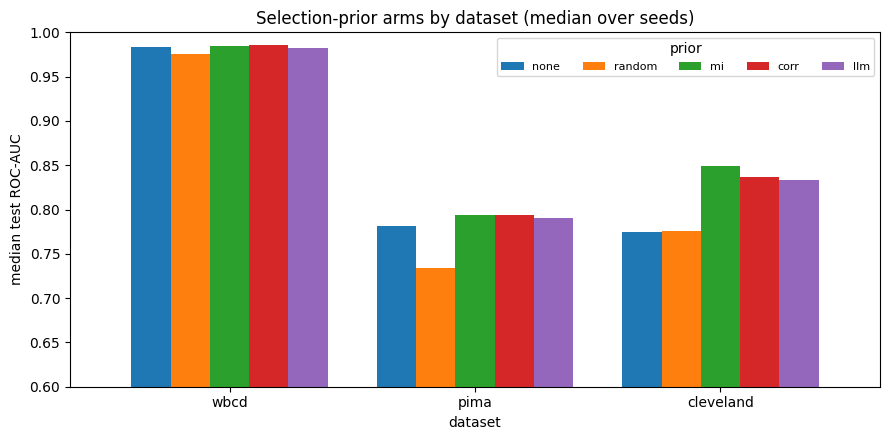

arm         none  random     mi   corr    llm
dataset                                      
cleveland  0.774   0.776  0.849  0.836  0.833
pima       0.782   0.734  0.794  0.794  0.791
wbcd       0.983   0.975  0.985  0.985  0.983


In [9]:
pivot = selection.groupby(["dataset", "arm"])["roc_auc"].median().unstack("arm")[SELECTION_ARMS]
ax = pivot.reindex(list(DATASETS)).plot(kind="bar", figsize=(9, 4.5), rot=0,
                                        ylim=(0.6, 1.0), width=0.8)
ax.set_ylabel("median test ROC-AUC"); ax.set_xlabel("dataset")
ax.set_title("Selection-prior arms by dataset (median over seeds)")
ax.legend(title="prior", ncol=5, fontsize=8)
plt.tight_layout(); plt.savefig(FIGURES / "selection_by_dataset.png", dpi=150); plt.show()
print(pivot.round(3).to_string())

In [10]:
def per_dataset_friedman(df, arms, metric="roc_auc"):
    rows, rank_rows = [], {}
    for key in DATASETS:
        wide = df[df.dataset == key].pivot_table(index="seed", columns="arm", values=metric)[arms].dropna()
        chi2, p = friedmanchisquare(*[wide[a].values for a in arms])
        ranks = wide.apply(lambda r: rankdata(-r.values), axis=1, result_type="expand")
        ranks.columns = arms
        avg = ranks.mean()
        rank_rows[key] = avg
        rows.append(dict(dataset=key, friedman_chi2=round(chi2, 2), p=round(p, 4),
                         **{a: round(avg[a], 2) for a in arms}))
    return pd.DataFrame(rows), pd.DataFrame(rank_rows).T[arms]

friedman, rank_table = per_dataset_friedman(selection, SELECTION_ARMS)
print("Per-dataset Friedman over seed-resamples, with average ranks (1 = best):")
print(friedman.to_string(index=False))
mean_rank = rank_table.mean(axis=0)
print("\nMean rank across datasets (descriptive):",
      {a: round(mean_rank[a], 2) for a in SELECTION_ARMS})
print("(A Demšar CD across 3 datasets is under-powered; the per-dataset Friedman is the inference.)")

Per-dataset Friedman over seed-resamples, with average ranks (1 = best):
  dataset  friedman_chi2      p  none  random   mi  corr  llm
     wbcd          18.95 0.0008  3.03    3.90 2.65  2.35 3.07
     pima          24.24 0.0001  3.35    4.00 2.68  2.50 2.47
cleveland          18.08 0.0012  3.55    3.67 2.83  2.47 2.48

Mean rank across datasets (descriptive): {'none': np.float64(3.31), 'random': np.float64(3.86), 'mi': np.float64(2.72), 'corr': np.float64(2.44), 'llm': np.float64(2.67)}
(A Demšar CD across 3 datasets is under-powered; the per-dataset Friedman is the inference.)


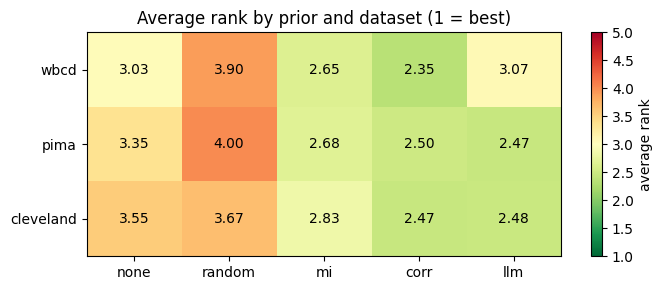

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.0))
im = ax.imshow(rank_table.values, cmap="RdYlGn_r", vmin=1, vmax=len(SELECTION_ARMS), aspect="auto")
ax.set_xticks(range(len(SELECTION_ARMS))); ax.set_xticklabels(SELECTION_ARMS)
ax.set_yticks(range(len(DATASETS))); ax.set_yticklabels(list(DATASETS))
for i in range(len(DATASETS)):
    for j in range(len(SELECTION_ARMS)):
        ax.text(j, i, f"{rank_table.values[i, j]:.2f}", ha="center", va="center", fontsize=10)
ax.set_title("Average rank by prior and dataset (1 = best)")
fig.colorbar(im, ax=ax, label="average rank")
plt.tight_layout(); plt.savefig(FIGURES / "rank_heatmap.png", dpi=150); plt.show()

In [12]:
def cliffs_delta(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    gt = sum((x > b).sum() for x in a); lt = sum((x < b).sum() for x in a)
    return (gt - lt) / (len(a) * len(b))

def holm(pvals):
    order = np.argsort(pvals); adj = np.empty(len(pvals)); running = 0.0
    for rank, i in enumerate(order):
        running = max(running, (len(pvals) - rank) * pvals[i]); adj[i] = min(running, 1.0)
    return adj

def paired_contrast(df, arm_a, arm_b, key, metric="roc_auc"):
    wide = df[df.dataset == key].pivot_table(index="seed", columns="arm", values=metric)
    a, b = wide[arm_a].values, wide[arm_b].values
    mask = ~(np.isnan(a) | np.isnan(b)); a, b = a[mask], b[mask]
    try: _, p = wilcoxon(a, b)
    except ValueError: p = 1.0
    return dict(dataset=key, contrast=f"{arm_a} vs {arm_b}", median_diff=np.median(a - b),
                cliffs_delta=cliffs_delta(a, b), p_raw=p)

rows = []
for key in DATASETS:
    rows += [paired_contrast(selection, "llm", "random", key),
             paired_contrast(selection, "llm", "mi", key),
             paired_contrast(construction, "llm", "random", key)]
contrasts = pd.DataFrame(rows)
contrasts["p_holm"] = np.nan
for key in DATASETS:                                   # Holm within each dataset
    mask = contrasts.dataset == key
    contrasts.loc[mask, "p_holm"] = holm(contrasts.loc[mask, "p_raw"].values)
print(contrasts.round(3).to_string(index=False))

  dataset      contrast  median_diff  cliffs_delta  p_raw  p_holm
     wbcd llm vs random        0.007         0.238  0.025   0.076
     wbcd     llm vs mi       -0.001        -0.217  0.032   0.076
     wbcd llm vs random        0.002         0.039  0.179   0.179
     pima llm vs random        0.070         0.537  0.000   0.000
     pima     llm vs mi        0.000         0.053  0.170   0.170
     pima llm vs random        0.029         0.564  0.000   0.000
cleveland llm vs random        0.047         0.447  0.007   0.022
cleveland     llm vs mi        0.000         0.019  0.614   0.614
cleveland llm vs random        0.001         0.180  0.106   0.213


        effective_length  structural_diversity  phenotype_coverage  invalids  depth  roc_auc
arm                                                                                         
none                 3.0                 0.079               0.154       0.0    3.0    0.826
random               3.0                 0.108               0.500       0.0    3.0    0.799
mi                   6.0                 0.304               0.500       0.0    4.0    0.853
corr                 7.0                 0.308               0.500       0.0    4.0    0.846
llm                  7.0                 0.204               0.500       0.0    4.0    0.843


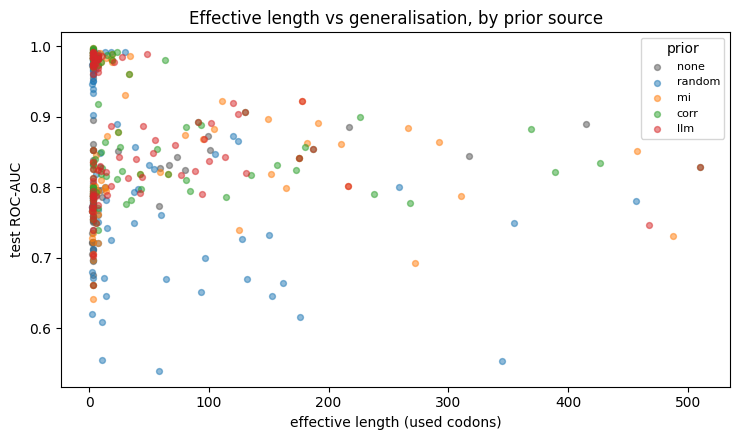

In [13]:
diag = (selection.groupby("arm")[["effective_length", "structural_diversity",
                                  "phenotype_coverage", "invalids", "depth", "roc_auc"]]
        .median().reindex(SELECTION_ARMS).round(3))
print(diag.to_string())

plt.figure(figsize=(7.5, 4.5))
colours = {"none": "#555", "random": "#1f77b4", "mi": "#ff7f0e",
           "corr": "#2ca02c", "llm": "#d62728"}
for arm in SELECTION_ARMS:
    sub = selection[selection.arm == arm]
    plt.scatter(sub["effective_length"], sub["roc_auc"], s=18, alpha=0.5,
                label=arm, color=colours[arm])
plt.xlabel("effective length (used codons)"); plt.ylabel("test ROC-AUC")
plt.title("Effective length vs generalisation, by prior source")
plt.legend(title="prior", fontsize=8)
plt.tight_layout(); plt.savefig(FIGURES / "length_vs_generalisation.png", dpi=150); plt.show()

In [14]:
def best_llm_rule(dataset_key):
    # reuse the strongest llm-arm phenotype from the selection study, on its own seed-split
    sub = selection[(selection.dataset == dataset_key) & (selection.arm == "llm")]
    row = sub.loc[sub["train_accuracy"].idxmax()]
    seed = int(row["seed"])
    d = prepare_dataset(dataset_key, seed)
    phen = row["phenotype"]
    used = used_features(phen, d["Xtr"].shape[1])
    m = evaluate_phenotype(phen, d["Xte"], d["yte"])
    readable = phen
    for i in sorted(used, reverse=True):
        readable = readable.replace(f"x[:,{i}]", d["features"][i])
    return dict(dataset=dataset_key, seed=seed, phenotype=phen, used=used,
                features=[d["features"][i] for i in used],
                roc_auc=round(m["roc_auc"], 3), f1=round(m["f1"], 3), rule=readable[:140])

best_rules = [best_llm_rule(k) for k in DATASETS]
for r in best_rules:
    print(f"\n{r['dataset']}: AUC={r['roc_auc']} f1={r['f1']}")
    print("  features:", r["features"]); print("  rule:", r["rule"])


wbcd: AUC=0.988 f1=0.913
  features: [np.str_('mean concavity'), np.str_('mean concave points'), np.str_('worst radius'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst compactness'), np.str_('worst concave points')]
  rule: add(sub(worst radius,worst area),sub(add(worst area,mean concavity),add(mul(mean concavity,worst concave points),sub(sub(mul(worst radius,me

pima: AUC=0.815 f1=0.567
  features: ['Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age']
  rule: add(add(add(sub(add(sub(add(add(sub(add(Age,Glucose),add(Glucose,2.0)),mul(BMI,0.5)),mul(DiabetesPedigreeFunction,Age)),Glucose),add(Glucose

cleveland: AUC=0.84 f1=0.804
  features: ['cp', 'thalach', 'exang', 'oldpeak', 'ca', 'thal']
  rule: add(sub(mul(cp,thalach),sub(add(exang,ca),add(cp,cp))),sub(add(add(sub(add(mul(thalach,ca),sub(thalach,ca)),add(sub(oldpeak,thalach),mul(tha


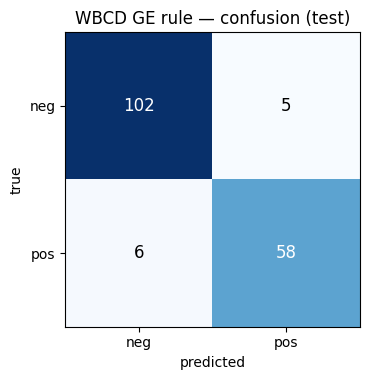

In [15]:
wbcd_rule = best_llm_rule("wbcd")
d = prepare_dataset("wbcd", wbcd_rule["seed"])
pred = np.asarray(eval(wbcd_rule["phenotype"], eval_namespace(d["Xte"])), float)
cm = confusion_matrix(d["yte"], (pred > 0).astype(int))
plt.figure(figsize=(4.3, 3.9)); plt.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=12)
plt.xticks([0, 1], ["neg", "pos"]); plt.yticks([0, 1], ["neg", "pos"])
plt.xlabel("predicted"); plt.ylabel("true"); plt.title("WBCD GE rule — confusion (test)")
plt.tight_layout(); plt.savefig(FIGURES / "wbcd_confusion.png", dpi=150); plt.show()

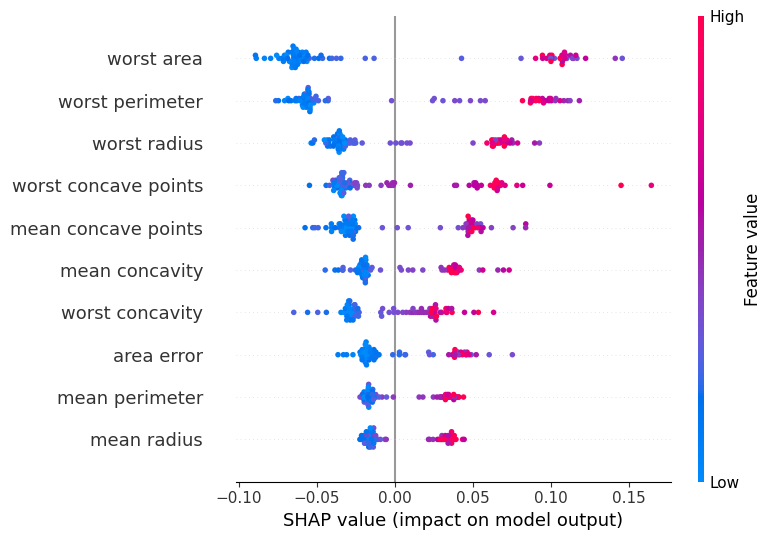

RF top-6 (SHAP): [np.str_('worst area'), np.str_('worst perimeter'), np.str_('worst radius'), np.str_('worst concave points'), np.str_('mean concave points'), np.str_('mean concavity')]
explanation: The classifier decides the positive class from mean concavity, mean concave points, worst radius, worst perimeter, worst area, worst compactness, worst concave points; larger values raise the positive score.
faithfulness: 0.429 (template; construction-limited)


In [16]:
wbcd_rule = best_llm_rule("wbcd")
d = prepare_dataset("wbcd", wbcd_rule["seed"])
rf = RandomForestClassifier(n_estimators=400, random_state=GLOBAL_SEED).fit(d["Xtr"], d["ytr"])
if HAS_SHAP:
    explainer = shap.TreeExplainer(rf); sv = explainer.shap_values(d["Xte"][:80])
    sv = sv[..., 1] if (isinstance(sv, np.ndarray) and sv.ndim == 3) else (sv[1] if isinstance(sv, list) else sv)
    shap.summary_plot(sv, d["Xte"][:80], feature_names=d["features"], show=False, max_display=10)
    plt.tight_layout(); plt.savefig(FIGURES / "wbcd_shap.png", dpi=150, bbox_inches="tight"); plt.show()
    rf_imp = np.abs(sv).mean(0); src = "SHAP"
else:
    rf_imp = rf.feature_importances_; src = "impurity"
rf_top = [d["features"][i] for i in np.argsort(rf_imp)[::-1][:6]]
print(f"RF top-6 ({src}):", rf_top)

phen = wbcd_rule["phenotype"]; used = wbcd_rule["used"]
rng = np.random.default_rng(0)
base_bal = balanced_accuracy_score(d["yte"], (np.asarray(eval(phen, eval_namespace(d["Xte"])), float) > 0))
imp = {}
for i in used:
    drops = []
    for _ in range(5):
        Xp = d["Xte"].copy(); Xp[:, i] = rng.permutation(Xp[:, i])
        p = np.asarray(eval(phen, eval_namespace(Xp)), float)
        drops.append(base_bal - balanced_accuracy_score(d["yte"], (p > 0)))
    imp[i] = float(np.mean(drops))
named = set(d["features"][i] for i in used)
top = set(d["features"][i] for i in sorted(imp, key=imp.get, reverse=True)[:max(1, len(imp)//2)])
faith = len(named & top) / len(named | top) if named else np.nan
print("explanation:", llm.explain_rule(phen, d["features"], used))
print("faithfulness:", round(faith, 3), "" if LIVE_LLM else "(template; construction-limited)")

In [17]:
print("=== baselines (median test ROC-AUC over seed-resamples) ===")
print(baselines.to_string())
print("\n=== selection arms (median test ROC-AUC) ===")
print(pivot.round(3).to_string())
print("\n=== construction arms (median test ROC-AUC) ===")
print(construction.groupby(["dataset", "arm"])["roc_auc"].median().unstack("arm").round(3).to_string())
print("\n=== per-dataset Friedman and average ranks (1=best) ===")
print(friedman.to_string(index=False))
print("mean rank across datasets:", {a: round(mean_rank[a], 2) for a in SELECTION_ARMS})
print("\n=== pre-registered contrasts (per dataset) ===")
print(contrasts[["dataset", "contrast", "median_diff", "cliffs_delta", "p_holm"]].round(3).to_string(index=False))
print("\n=== BDS diagnostics (median by arm) ===")
print(diag.to_string())
print("\nLLM prior: live API =", LIVE_LLM)

=== baselines (median test ROC-AUC over seed-resamples) ===
dataset       cleveland   pima   wbcd
model                                
LogReg            0.907  0.838  0.997
MLP               0.884  0.771  0.995
RandomForest      0.903  0.828  0.991
SVM               0.904  0.826  0.997
XGBoost           0.870  0.785  0.994

=== selection arms (median test ROC-AUC) ===
arm         none  random     mi   corr    llm
dataset                                      
cleveland  0.774   0.776  0.849  0.836  0.833
pima       0.782   0.734  0.794  0.794  0.791
wbcd       0.983   0.975  0.985  0.985  0.983

=== construction arms (median test ROC-AUC) ===
arm          llm  random    raw
dataset                        
cleveland  0.794   0.768  0.774
pima       0.815   0.787  0.782
wbcd       0.982   0.984  0.983

=== per-dataset Friedman and average ranks (1=best) ===
  dataset  friedman_chi2      p  none  random   mi  corr  llm
     wbcd          18.95 0.0008  3.03    3.90 2.65  2.35 3.07
     pim